In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
files = {
    "50kΩ test 1": "C:\\Users\\carlo\\OneDrive - Universidade de Lisboa\\Documents\\GitHub\\Wearables-Glove-Project\\mechanical test\\50kohm_1_test_adc_data_20260612_123857.csv",
    "50kΩ test 2": "C:\\Users\\carlo\\OneDrive - Universidade de Lisboa\\Documents\\GitHub\\Wearables-Glove-Project\\mechanical test\\50kohm_2_test_adc_data_20260612_124824.csv",
    "50kΩ test 3": "C:\\Users\\carlo\\OneDrive - Universidade de Lisboa\\Documents\\GitHub\\Wearables-Glove-Project\\mechanical test\\50kohm_3_test_adc_data_20260612_125644.csv",
    "200kΩ":       "C:\\Users\\carlo\\OneDrive - Universidade de Lisboa\\Documents\\GitHub\\Wearables-Glove-Project\\mechanical test\\200kohm_test_adc_data_20260612_130535.csv",
    "250kΩ":       "C:\\Users\\carlo\\OneDrive - Universidade de Lisboa\\Documents\\GitHub\\Wearables-Glove-Project\\mechanical test\\250kohm_test_adc_data_20260612_123025.csv",
}

dfs = {}
for label, fname in files.items():
    df = pd.read_csv(fname, parse_dates=["Timestamp"])
    df.replace(-1.0, np.nan, inplace=True)
    df["elapsed_s"] = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds()
    dfs[label] = df
    print(f"{label}: {len(df)} samples, duration {df['elapsed_s'].iloc[-1]:.1f}s")

50kΩ test 1: 5593 samples, duration 280.0s
50kΩ test 2: 4209 samples, duration 210.9s
50kΩ test 3: 4202 samples, duration 210.8s
200kΩ: 5125 samples, duration 256.8s
250kΩ: 3604 samples, duration 180.5s


## Individual plots — Channel 1 per resistor value

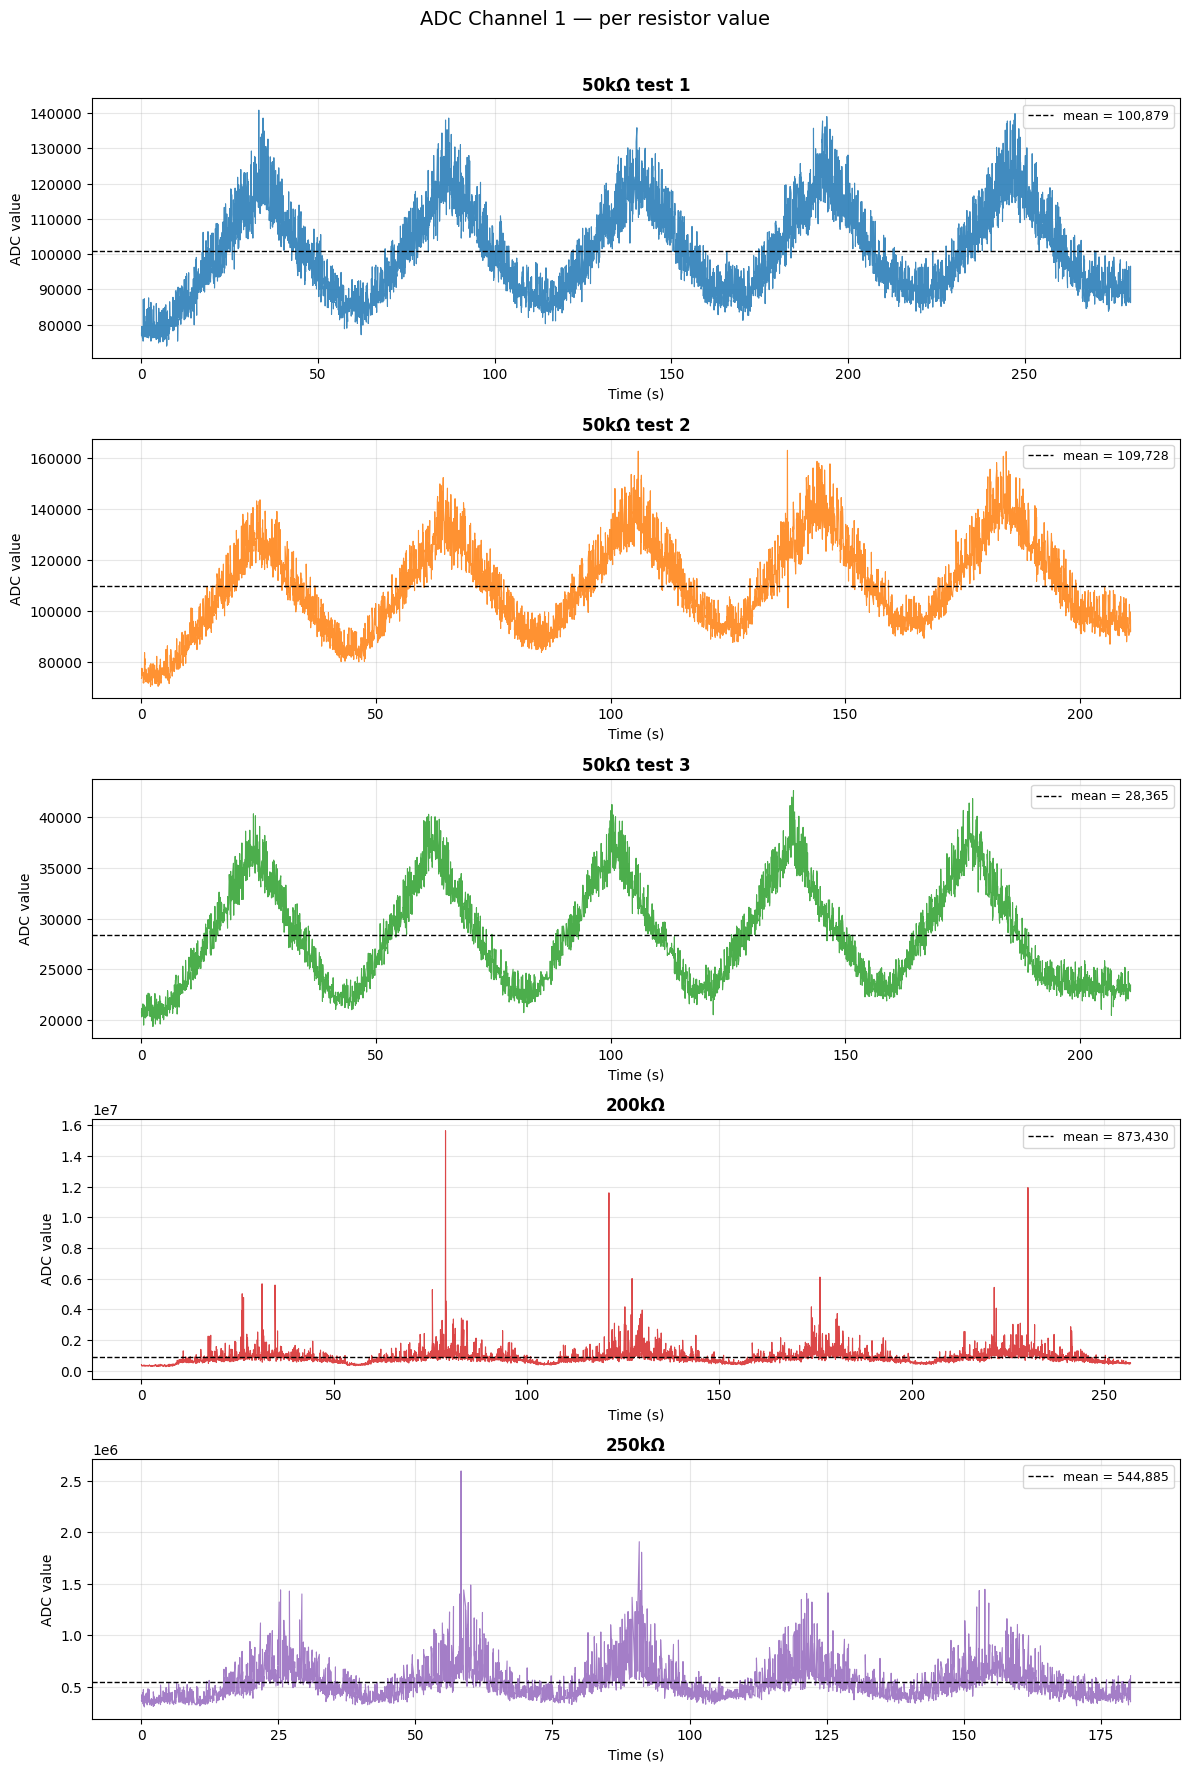

In [4]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(len(dfs), 1, figsize=(12, 3.5 * len(dfs)), sharex=False)

for ax, (label, df), color in zip(axes, dfs.items(), colors):
    ax.plot(df["elapsed_s"], df["Channel_1"], color=color, linewidth=0.8, alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("ADC value")
    ax.grid(True, alpha=0.3)
    mean_val = df["Channel_1"].mean()
    ax.axhline(mean_val, color="black", linestyle="--", linewidth=1,
               label=f"mean = {mean_val:,.0f}")
    ax.legend(fontsize=9)

plt.suptitle("ADC Channel 1 — per resistor value", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("adc_individual_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary statistics

In [6]:
rows = []
for label, df in dfs.items():
    ch = df["Channel_1"].dropna()
    rows.append({
        "Label":        label,
        "Samples":      len(ch),
        "Mean ADC":     f"{ch.mean():,.1f}",
        "Std ADC":      f"{ch.std():,.1f}",
        "Min ADC":      f"{ch.min():,.1f}",
        "Max ADC":      f"{ch.max():,.1f}",
        "Duration (s)": f"{df['elapsed_s'].iloc[-1]:.1f}",
    })

pd.DataFrame(rows).set_index("Label")

,Samples,Mean ADC,Std ADC,Min ADC,Max ADC,Duration (s)
Label,,,,,,
50kΩ test 1,5593,"100,879.3","12,526.3","73,885.4","140,882.4",280.0
50kΩ test 2,4209,"109,727.7","17,384.2","70,412.0","162,837.0",210.9
50kΩ test 3,4202,"28,365.2","4,910.4","19,353.0","42,633.2",210.8
200kΩ,5124,"873,430.1","539,433.2","258,581.4","15,650,118.0",256.8
250kΩ,3604,"544,884.5","179,594.3","303,846.1","2,594,078.0",180.5
